In [5]:
#import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [6]:
#load the data set
df=pd.read_csv("data.csv")

In [7]:
#check the shape of the data set
df.shape

(171, 1204)

In [8]:
#check the first 5 rows of the data set
df.head(5)

,MATS3v,nHBint10,MATS3s,MATS3p,nHBDon_Lipinski,minHBint8,MATS3e,MATS3c,minHBint2,MATS3m,...,WTPT-4,WTPT-5,ETA_EtaP_L,ETA_EtaP_F,ETA_EtaP_B,nT5Ring,SHdNH,ETA_dEpsilon_C,MDEO-22,Class
0,0.0908,0,0.0075,0.0173,0,0.0,-0.0436,0.0409,0.0,0.1368,...,0.0000,0.0000,0.1780,1.5488,0.0088,0,0.0,-0.0868,0.00,NonToxic
1,0.0213,0,0.1144,-0.0410,0,0.0,0.1231,-0.0316,0.0,0.1318,...,8.8660,19.3525,0.1739,1.3718,0.0048,2,0.0,-0.0810,0.25,NonToxic
2,0.0018,0,-0.0156,-0.0765,2,0.0,-0.1138,-0.1791,0.0,0.0615,...,5.2267,27.8796,0.1688,1.4395,0.0116,2,0.0,-0.1004,0.00,NonToxic
3,-0.0251,0,-0.0064,-0.0894,3,0.0,-0.0747,-0.1151,0.0,0.0361,...,7.7896,24.7336,0.1702,1.4654,0.0133,2,0.0,-0.1010,0.00,NonToxic
4,0.0135,0,0.0424,-0.0353,0,0.0,-0.0638,0.0307,0.0,0.0306,...,12.3240,19.7486,0.1789,1.4495,0.0120,2,0.0,-0.1071,0.00,NonToxic


In [9]:
#check the columns in the data set
df.columns  

Index(['MATS3v', 'nHBint10', 'MATS3s', 'MATS3p', 'nHBDon_Lipinski',
       'minHBint8', 'MATS3e', 'MATS3c', 'minHBint2', 'MATS3m',
       ...
       'WTPT-4', 'WTPT-5', 'ETA_EtaP_L', 'ETA_EtaP_F', 'ETA_EtaP_B', 'nT5Ring',
       'SHdNH', 'ETA_dEpsilon_C', 'MDEO-22', 'Class'],
      dtype='str', length=1204)

In [10]:
#check the type 
df.dtypes 

MATS3v             float64
nHBint10             int64
MATS3s             float64
MATS3p             float64
nHBDon_Lipinski      int64
                    ...   
nT5Ring              int64
SHdNH              float64
ETA_dEpsilon_C     float64
MDEO-22            float64
Class                  str
Length: 1204, dtype: object

In [11]:
#info about data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Columns: 1204 entries, MATS3v to Class
dtypes: float64(1003), int64(200), str(1)
memory usage: 1.6 MB


In [12]:
#check for the sum of the null values and the sum
df.isna().sum()

MATS3v             0
nHBint10           0
MATS3s             0
MATS3p             0
nHBDon_Lipinski    0
                  ..
nT5Ring            0
SHdNH              0
ETA_dEpsilon_C     0
MDEO-22            0
Class              0
Length: 1204, dtype: int64

In [13]:
#check for duplicates
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
166    False
167    False
168    False
169    False
170    False
Length: 171, dtype: bool

In [14]:
#statistical summary of numerical features
df.describe()

,MATS3v,nHBint10,MATS3s,MATS3p,nHBDon_Lipinski,minHBint8,MATS3e,MATS3c,minHBint2,MATS3m,...,WTPT-3,WTPT-4,WTPT-5,ETA_EtaP_L,ETA_EtaP_F,ETA_EtaP_B,nT5Ring,SHdNH,ETA_dEpsilon_C,MDEO-22
count,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,...,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000
mean,-0.031244,0.315789,-0.001001,-0.061501,0.994152,0.677770,-0.025418,-0.053289,1.569251,0.003226,...,23.229975,8.134013,13.490291,0.202529,1.235093,0.011316,1.467836,0.004820,-0.085088,0.061702
std,0.063559,0.762918,0.063928,0.072891,1.108773,1.647322,0.078645,0.109463,2.497362,0.074076,...,6.440623,4.436831,6.229089,0.024356,0.137024,0.005482,1.013361,0.044475,0.029273,0.241896
min,-0.311500,0.000000,-0.184600,-0.348500,0.000000,0.000000,-0.211900,-0.472900,-0.708700,-0.198700,...,0.000000,0.000000,0.000000,0.163600,0.811500,0.001400,0.000000,0.000000,-0.202700,0.000000
25%,-0.066700,0.000000,-0.036000,-0.099550,0.000000,0.000000,-0.066550,-0.118050,0.000000,-0.052350,...,19.249600,5.164700,8.819950,0.182450,1.149750,0.007550,1.000000,0.000000,-0.099500,0.000000
50%,-0.032500,0.000000,-0.002000,-0.059400,1.000000,0.000000,-0.037200,-0.042400,0.000000,-0.001600,...,23.151200,7.848200,13.342700,0.199600,1.238800,0.010700,1.000000,0.000000,-0.082400,0.000000
75%,0.004850,0.000000,0.029000,-0.017100,2.000000,0.000000,0.002650,0.014300,4.897450,0.056550,...,26.958050,10.683950,19.319450,0.219700,1.325350,0.013900,2.000000,0.000000,-0.066350,0.000000
max,0.141100,4.000000,0.218100,0.129000,6.000000,8.141400,0.249500,0.212200,7.740800,0.168400,...,41.380000,20.805400,27.879600,0.272100,1.548800,0.034600,5.000000,0.429200,-0.007300,2.636100


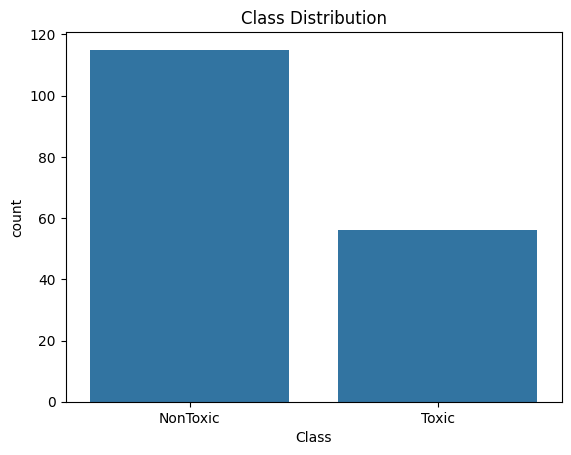

In [15]:
#class distribution
sns.countplot(x="Class" , data=df)
plt.title("Class Distribution")
plt.show() 

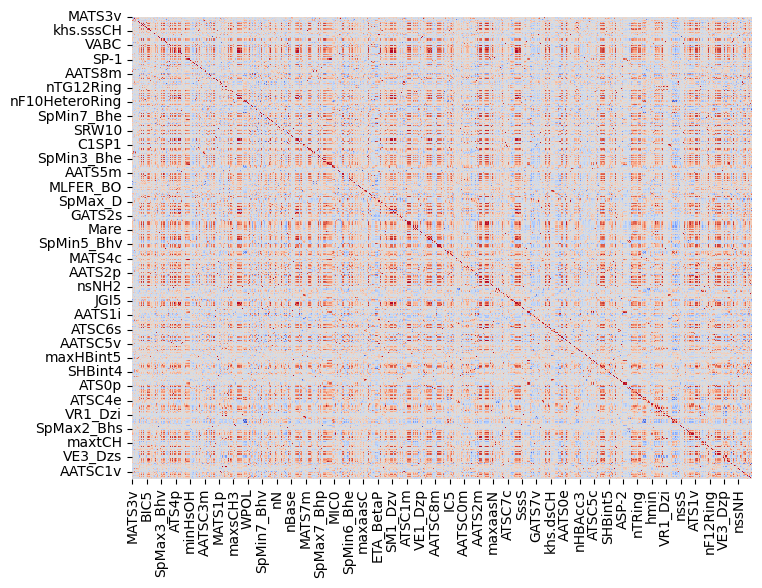

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),cmap="coolwarm",cbar=False)
plt.show()

In [17]:
x=df.drop("Class" , axis=1)
y=df["Class"]

In [18]:
le=LabelEncoder()
y=le.fit_transform(y)

In [19]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
x_imputed = pd.DataFrame(imputer.fit_transform(x), columns=x.columns)

In [ ]:
# create and fit the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

In [40]:
# scale features (needed for cross-validation and model training)
scaler = StandardScaler()
x_scaled = pd.DataFrame(scaler.fit_transform(x_imputed), columns=x_imputed.columns)

# perform cross-validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, x_scaled, y, cv=kfold, scoring="accuracy")
print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross-validation scores: [0.6        0.61764706 0.64705882 0.58823529 0.61764706]
Mean CV Accuracy: 0.6141176470588235


In [41]:
# scale features (needed for cross-validation and model training)
scaler = StandardScaler()
x_scaled = pd.DataFrame(scaler.fit_transform(x_imputed), columns=x_imputed.columns)

X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42, stratify=y)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import randint
import pandas as pd

# ========= STEP 0: Baseline model =========
# Fit your existing RF model (rf_model) and evaluate
rf_baseline = rf_model
rf_baseline.fit(X_train, y_train)

y_pred_base = rf_baseline.predict(X_test)

print("=== Baseline performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_base))
print("\nClassification report:\n", classification_report(y_test, y_pred_base))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_base))

# ========= STEP 1: Grid search tuning =========
rf_grid_base = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False],
}

grid_search = GridSearchCV(
    estimator=rf_grid_base,
    param_grid=param_grid,
    cv=5,
    scoring="f1",      # change to "accuracy" or "roc_auc" if you prefer
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print("\n=== GridSearch best params ===")
print(grid_search.best_params_)

rf_grid = grid_search.best_estimator_

y_pred_grid = rf_grid.predict(X_test)

print("\n=== GridSearch performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_grid))
print("\nClassification report:\n", classification_report(y_test, y_pred_grid))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_grid))

# ========= STEP 2: Random search tuning =========
rf_random_base = RandomForestClassifier(random_state=42, n_jobs=-1)

param_distributions = {
    "n_estimators": randint(100, 501),
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": randint(2, 21),
    "min_samples_leaf": randint(1, 11),
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False],
}

random_search = RandomizedSearchCV(
    estimator=rf_random_base,
    param_distributions=param_distributions,
    n_iter=50,         # increase for more thorough search
    cv=5,
    scoring="f1",
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

random_search.fit(X_train, y_train) 
rf_random = random_search.best_estimator_

y_pred_random = rf_random.predict(X_test)

print("\n=== RandomizedSearch performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_random))
print("\nClassification report:\n", classification_report(y_test, y_pred_random))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_random))

# ========= STEP 3: Summary table (with & without tuning) =========
results = pd.DataFrame({
    "Model": ["Baseline", "GridSearch RF", "RandomSearch RF"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_base),
        accuracy_score(y_test, y_pred_grid),
        accuracy_score(y_test, y_pred_random),
    ]
    # you can add other metrics here (e.g. F1, ROC_AUC)
})

print("\n=== Summary of accuracies ===")
print(results)


=== Baseline performance ===
Accuracy: 0.6571428571428571

Classification report:
               precision    recall  f1-score   support

           0       0.68      0.96      0.79        24
           1       0.00      0.00      0.00        11

    accuracy                           0.66        35
   macro avg       0.34      0.48      0.40        35
weighted avg       0.46      0.66      0.54        35


Confusion matrix:
 [[23  1]
 [11  0]]
Fitting 5 folds for each of 432 candidates, totalling 2160 fits

=== GridSearch best params ===
{'bootstrap': False, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

=== GridSearch performance ===
Accuracy: 0.6857142857142857

Classification report:
               precision    recall  f1-score   support

           0       0.71      0.92      0.80        24
           1       0.50      0.18      0.27        11

    accuracy                           0.69        35
   macro avg       

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6571428571428571
              precision    recall  f1-score   support

           0       0.68      0.96      0.79        24
           1       0.00      0.00      0.00        11

    accuracy                           0.66        35
   macro avg       0.34      0.48      0.40        35
weighted avg       0.46      0.66      0.54        35



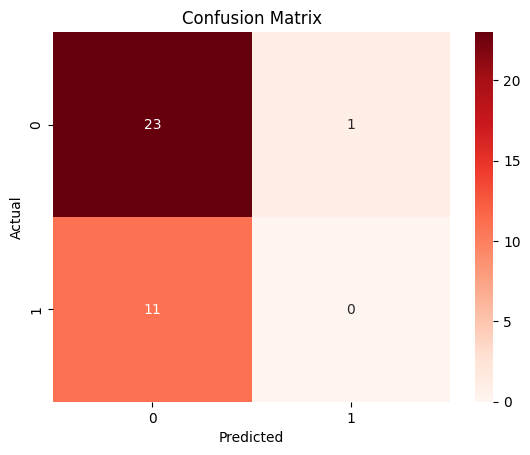

In [140]:
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True,
            fmt="d",
            cmap="Reds")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

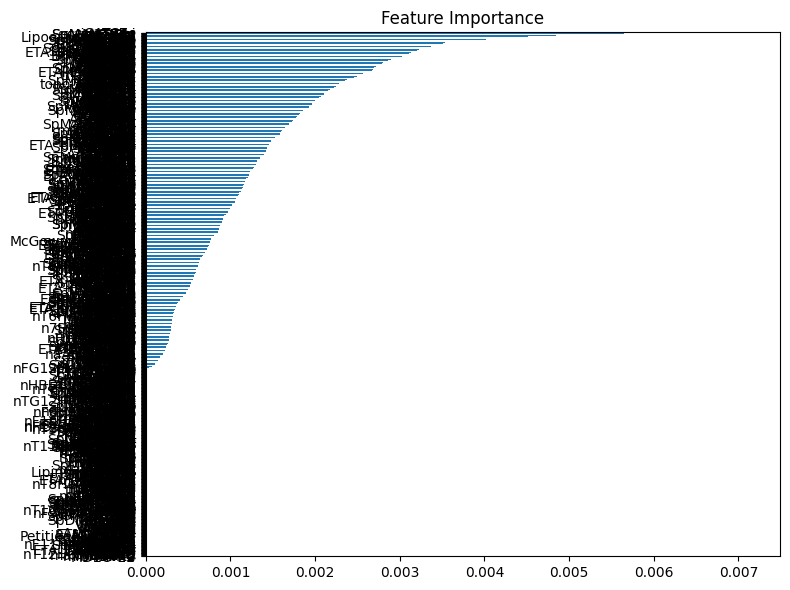

In [ ]:
# plot feature importances
importances = rf_model.feature_importances_
feat_importance = pd.Series(importances, index=x.columns)
feat_importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.tight_layout()
plt.show()